# 1. **Preprocessing and EDA Pipeline**
    Here, we create a structured pipeline using scikit-learn's Pipeline and ColumnTransformer. This ensures that the preprocessing steps are applied constantly to both training and testing data. 

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

#1. Loading the dataset
data = pd.read_csv('Vehicle Price.csv') 

def eda_report(df):
    print("--- Dataset Info ---")
    print(df.info())
    print("\n--- Missing Values ---")
    print(df.isnull().sum())
    
    # Visualization: Target Distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(df['Price'], kde=True, color='blue')
    plt.title('Distribution of Vehicle Prices')
    plt.show()

    # Visualization: Correlation Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
    plt.title('Feature Correlation')
    plt.show()

# 2. Build the Preprocessing Pipeline
def get_preprocessing_pipeline(numeric_features, categorical_features):
    # Numeric: Impute missing with median -> Scale
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # Categorical: Impute missing with 'missing' -> OneHot Encode
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Combine into a ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])
    
    return preprocessor

In [16]:
# Check the exact column names
print(data.columns.tolist())

['name', 'description', 'make', 'model', 'year', 'price', 'engine', 'cylinders', 'fuel', 'mileage', 'transmission', 'trim', 'body', 'doors', 'exterior_color', 'interior_color', 'drivetrain']


# 2. **Model Training and Hyperparameter Tuning**
     In this section, we are combining the preprocessor and Random Forest Model into a single final pipeline.
     Then, we use GridSearchCV to find optimal number of trees and depth

In [17]:
warnings.filterwarnings("ignore")
print(f"Missing prices before cleaning: {data['price'].isnull().sum()}")
data = data.dropna(subset=['price'])
# Define Features
drop_cols=['price','name','description']
X = data.drop(columns=drop_cols)
y = data['price']

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the full pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', get_preprocessing_pipeline(numeric_cols, categorical_cols)),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Hyperparameter Tuning via Grid Search
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(full_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1,verbose=0)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Missing prices before cleaning: 23
Best Parameters: {'regressor__max_depth': None, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}


# 3. Evaluation Metrics
    To evaluate the regression performance, we use Mean Squared Error (MSE) and the Coefficient of Determination (R^2).

Mean Squared Error: 65164675.93
R-squared Score: 0.7866


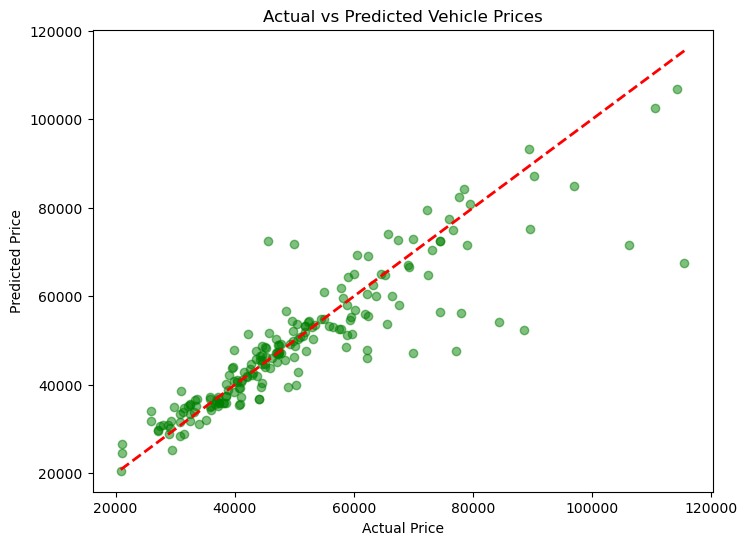

In [18]:
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Plotting Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Vehicle Prices')
plt.show()

# 4. Saving the Final Model
    The Final Step is to serialize the entire pipeline (including the scale, imputer and the trained model) into a .pkl file using pickle. This allows us to deploy the model and pass raw data into it later without manual preprocessing

In [19]:
# Saving the final model
with open('vehicle_price_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("Model saved successfully as vehicle_price_model.pkl")

Model saved successfully as vehicle_price_model.pkl
